In [16]:
#__ACTIVITY 3.1__
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

# 1. Setup Parameters (Based on your Activity 11 & 12)
IMG_SHAPE = (224, 224, 3)
NUM_CLASSES = 38  # Your dataset has 38 classes

# 2. Re-create the Model (Fixes NameError)
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base layers for Phase 1

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 3. Compile the Model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model fixed, defined, and compiled successfully!")
model.summary()

Model fixed, defined, and compiled successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
#__ACTIVITY 3.2__
import tensorflow as tf
from tensorflow import keras

# Define training callbacks
callbacks = [
    # 1. Save best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        "plant_care_model_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # 2. Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    # 3. Stop training if no improvement (Prevents overfitting)
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured successfully:")
print("  1. ModelCheckpoint - Will save to 'plant_care_model_best.keras'")
print("  2. ReduceLROnPlateau - Will drop learning rate if val_loss stalls")
print("  3. EarlyStopping - Will end training if the model stops improving")

Callbacks configured successfully:
  1. ModelCheckpoint - Will save to 'plant_care_model_best.keras'
  2. ReduceLROnPlateau - Will drop learning rate if val_loss stalls
  3. EarlyStopping - Will end training if the model stops improving


In [18]:
#__ACTIVITY 3.3__
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import os
import kagglehub

# --- 1. DOWNLOAD AND DYNAMICALLY LOCATE DATASET ---
# This downloads the dataset and returns the local path on the Colab server
base_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# Use os.path.join to build the correct Linux paths for Colab
# Based on the dataset structure, we add the subfolders:
train_dir = os.path.join(base_path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train")
valid_dir = os.path.join(base_path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "valid")

# Verify the paths exist before loading
if os.path.exists(train_dir):
    print(f"✅ Found training directory at: {train_dir}")
else:
    # If the subfolder names are slightly different, list the directory to see them
    print("❌ Path error. Actual folders in download:", os.listdir(base_path))

# --- 2. LOAD DATASETS ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# --- 3. TRAIN THE MODEL ---
# (Ensure your Activity 3.1 model and 3.2 callbacks are defined)
print("\n🚀 Starting Phase 1 Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
✅ Found training directory at: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.

🚀 Starting Phase 1 Training...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2642 - loss: 2.7723
Epoch 1: val_accuracy improved from -inf to 0.67078, saving model to plant_care_model_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3804s 2s/step - accuracy: 0.2643 - loss: 2.7720 - val_accuracy: 0.6708 - val_loss: 1.3280 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5786 - loss: 1.4779
Epoch 2: val_accuracy improved from 0.67078 to 0.72957, saving model to plant_care_model_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3829s 2s/step - accuracy: 0.5786 - loss: 1.4779 - val_accuracy: 0.7296 - val_loss: 1.0057 - lear

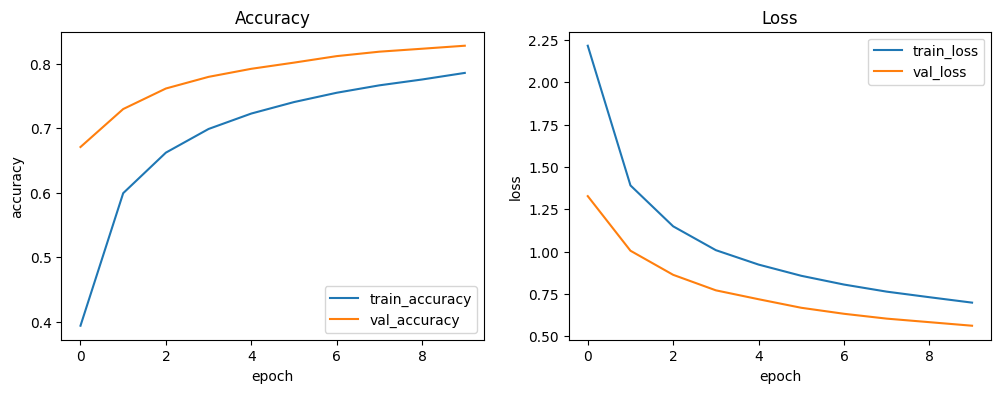

In [19]:
#__ACTIVITY 3.4__
import matplotlib.pyplot as plt

# ---------------- Plot training curves ----------------
plt.figure(figsize=(12,4))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')

plt.show()